In [118]:
#Required Libaries
import time
import matplotlib.pyplot as plt
import numpy as np

In [119]:
#Creates an array of size n
def createArray(n):
    return list(np.random.randint(100, size = n))

def createTestData():
    testData = []
    for i in range(0, 500):
        testData.append(createArray(i))
    return testData

In [120]:
#Insert sort implementation
def InsertionSort(arr):
    for i in range(1, len(arr)):
        key = [i]
        j = i-1
        #If the checkeed element is greater than the key then we move those array elements to one position ahead
        while j>=0 and key<arr[j]: 
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key

def TimeInsertionSort(arr):
    start = time.perf_counter()
    InsertionSort(arr)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [121]:
#Quick sort Implementation
def swap(arr, i, j):
    arr[i], arr[j] = arr[j], arr[i]

def partition(arr, low, high):
    # Choosing the piviot 
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] < pivot:
            i += 1
            swap(arr, i, j)
    swap(arr, i + 1, high)
    return i + 1

def QuickSort(arr, low, high):
    if low < high:
        pi = partition(arr, low, high)
        QuickSort(arr, low, pi - 1)
        QuickSort(arr, pi + 1, high)

def TimeQuickSort(arr):
    start = time.perf_counter()
    QuickSort(arr, 0, len(arr) -1)
    end = time.perf_counter()
    if(TestCorrectness(arr)):
        return end-start
    return -1

In [122]:
def TestCorrectness(arr):
    buffer_array = arr
    buffer_array.sort()
    return arr == buffer_array

In [123]:
#Needs to make sure the size N is in the Y axis
def main():
    testData = createTestData()
    insertionData = []
    quickData = []
    testDataLength = []
    for testArray in testData:
        testDataLength.append(len(testArray))
        insertionData.append(TimeInsertionSort(testArray.copy()))
        quickData.append(TimeQuickSort(testArray.copy()))
    #If there is a -1 in the data, that means that the data for insertion or quick sort failed to pass the correctness test
    if(-1 in insertionData or -1 in quickData):
        print("One of the arrays were not sorted correctly.")
        return 1
    fig = plt.figure()
    fig, ax = plt.subplots(layout = "constrained")
    ax.plot(testDataLength, insertionData, label = "Insertion Sort")
    ax.plot(testDataLength, quickData, label = "Quick Sort")
    ax.set_ylabel("Time")
    ax.set_xlabel("Size of array")
    ax.legend()

<Figure size 640x480 with 0 Axes>

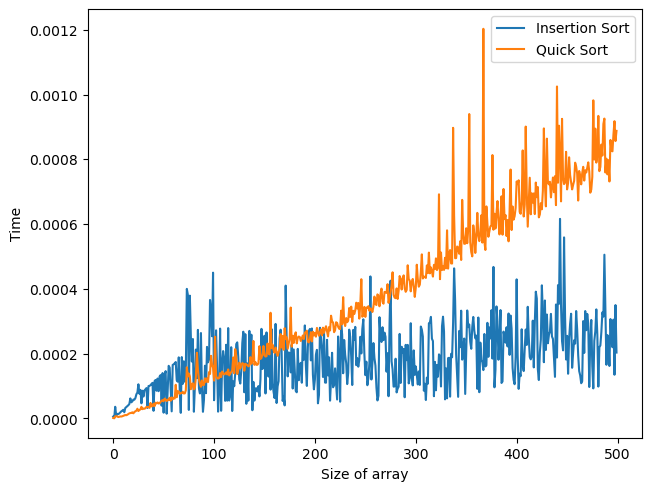

In [124]:
main()